In [28]:
!pip install catboost

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb
import catboost as cb
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

SEED = 42
N_FOLDS = 5
ID_COL = 'front_id'
TARGET_COL = 'target_value'

# Прогнозирование отклика на кредитный оффер

**Задача:** оценить вероятность согласия клиента на кредитное предложение.Модель должна оценивать, примет ли клиент конкретный оффер по кредитному продукту: бизнес-кредиту, возобновляемой кредитной линии или овердрафту.

**Метрика:** ROC AUC

**Лучший результат:** OOF AUC ≈ 0.837 (простое среднее 7 моделей)

## Подход

1. Feature Engineering: временные признаки, missing-флаги, interactions, target encoding
2. 7 моделей с 5-Fold Stratified CV на двух наборах признаков
3. Финальный ансамбль: простое среднее всех моделей

Загрузка данных

In [30]:
train = pd.read_csv('train_apps.csv')
test = pd.read_csv('test_apps.csv')

print(f"Train: {train.shape}, Test: {test.shape}")
print(f"Target rate: {train[TARGET_COL].mean():.4f} ({train[TARGET_COL].sum()}/{len(train)})")

train_ids = train[ID_COL].values
train_target = train[TARGET_COL].values.copy()
print(f"Saved target: {len(train_target)}, pos={train_target.sum():.0f}")

train['is_train'] = 1
test['is_train'] = 0
test[TARGET_COL] = np.nan

df = pd.concat([train, test], axis=0, ignore_index=True)
print(f"Combined: {df.shape}")

Train: (145241, 28), Test: (36311, 27)
Target rate: 0.0609 (8846/145241)
Saved target: 145241, pos=8846
Combined: (181552, 29)


# 2. Feature Engineering
Исходные 27 столбцов расширены до 57 признаков за счёт четырёх групп
дополнительных переменных.

 - Сначала обрботаем временные признаки

 Столбец `decision_day` содержит дату принятия решения по заявке.
Из неё извлекаются:
- **Месяц** — сезонность спроса на кредитные продукты
- **День недели** — различия в поведении клиентов в разные дни
- **День месяца** — возможные паттерны (начало/конец месяца)
- **Квартал** — квартальная динамика
- **Порядковый номер дня** — линейный тренд во времени (наиболее важный
  из временных признаков, входит в топ-5 по значимости)

In [31]:
df['decision_day_dt'] = pd.to_datetime(df['decision_day'], errors='coerce')

df['dt_month'] = df['decision_day_dt'].dt.month
df['dt_dayofweek'] = df['decision_day_dt'].dt.dayofweek
df['dt_day'] = df['decision_day_dt'].dt.day
df['dt_quarter'] = df['decision_day_dt'].dt.quarter
min_date = df['decision_day_dt'].min()
df['dt_ordinal'] = (df['decision_day_dt'] - min_date).dt.days

date_features = ['dt_month', 'dt_dayofweek', 'dt_day', 'dt_quarter', 'dt_ordinal']
df.drop(['decision_day', 'decision_day_dt'], axis=1, inplace=True)

- Кодировнаие категориальных признаков

В данных два категориальных столбца
- **db_group_last** — группа кредитного продукта
- **fl_adminarea** — регион клиента

Пропуски заменяются специальной меткой , после чего значения
кодируются числами через `LabelEncoder`

In [32]:
cat_features = ['db_group_last', 'fl_adminarea']

for col in cat_features:
    le = LabelEncoder()
    df[col] = df[col].fillna('__MISSING__').astype(str)
    df[col] = le.fit_transform(df[col])

Оставляем только полезные признаки

Создаем бинарные индикаторы для пропущенных значений

Дополнительно создан признак **total_missing_count** — общее число пропусков
по строке


In [33]:
useful_missing = [
    'overdraft_app_term_max_360', 'loan_rev_max_start_non_fin',
    'loan_rev_min_start_fin', 'days_from_authperson_registration',
    'app_term_mean_360', 'sum_deb_ul_90', 'corp_credit_products',
]

missing_flags = []
for col in useful_missing:
    if col in df.columns:
        flag = f'{col}_is_missing'
        df[flag] = df[col].isnull().astype(np.int8)
        missing_flags.append(flag)

df['total_missing_count'] = df[
    [c for c in df.columns if c not in [ID_COL, TARGET_COL, 'is_train']]
].isnull().sum(axis=1)
missing_flags.append('total_missing_count')

Дополнительные производные признаки
Созданы на основе предметной логики кредитного скоринга.

**Кредитная история и обороты:**
- `loan_rev_x_cnt_cred` — произведение давности кредита на количество
  кредитовых операций
- `loan_ops_total` — общее число дебетовых и кредитовых операций по кредитам
- `loan_deb_cred_diff` — разность дебетовых и кредитовых операций

**Лимиты и суммы:**
- `loan_to_overdraft_max` — отношение суммы кредита к максимальному лимиту
  овердрафта
- `overdraft_limit_range` — разброс лимитов овердрафта

**Ставки и условия:**
- `rate_ratio` — отношение предложенной ставки к ставке ЦБ

**Активность клиента:**
- `corp_engagement` — произведение числа событий в корпоративном кабинете
  на медианное время сессии
- `deb_ul_ip_trend` — тренд дебетовых операций

In [34]:
interaction_features = []

df['loan_rev_x_cnt_cred'] = df['loan_rev_max_start_non_fin'] * df['cnt_cred_loan_90']
interaction_features.append('loan_rev_x_cnt_cred')

df['loan_rev_x_overdraft_max'] = df['loan_rev_max_start_non_fin'] * df['overdraft_limit_max']
interaction_features.append('loan_rev_x_overdraft_max')

df['loan_rev_x_loan_amount'] = df['loan_rev_max_start_non_fin'] * df['loan_amount_last']
interaction_features.append('loan_rev_x_loan_amount')

df['loan_ops_total'] = df['cnt_deb_loan_90'] + df['cnt_cred_loan_90']
interaction_features.append('loan_ops_total')

df['loan_ops_ratio_safe'] = df['cnt_deb_loan_90'] / (df['cnt_cred_loan_90'].clip(lower=0.01))
interaction_features.append('loan_ops_ratio_safe')

df['overdraft_limit_range'] = df['overdraft_limit_max'] - df['overdraft_limit_min']
interaction_features.append('overdraft_limit_range')

df['loan_to_overdraft_max'] = df['loan_amount_last'] / (df['overdraft_limit_max'].clip(lower=0.01))
interaction_features.append('loan_to_overdraft_max')

df['rate_ratio'] = df['offered_rate'] / (df['cb_rate'].clip(lower=0.001))
interaction_features.append('rate_ratio')

df['deb_ul_ip_trend'] = df['cnt_deb_ul_ip_90'] - df['cnt_deb_ul_ip_30']
interaction_features.append('deb_ul_ip_trend')

df['deb_ul_90_to_30_ratio'] = df['cnt_deb_ul_ip_90'] / (df['cnt_deb_ul_ip_30'].clip(lower=0.01))
interaction_features.append('deb_ul_90_to_30_ratio')

df['loan_rev_range'] = df['loan_rev_max_start_non_fin'] - df['loan_rev_min_start_fin']
interaction_features.append('loan_rev_range')

df['corp_engagement'] = df['count_all_corp_dashboard_events'] * df['p75_time_spent_minutes']
interaction_features.append('corp_engagement')

df['deb_ul_diff_90_30'] = df['sum_deb_ul_90'] - df['cnt_deb_ul_ip_30']
interaction_features.append('deb_ul_diff_90_30')

df['loan_deb_cred_diff'] = df['cnt_deb_loan_90'] - df['cnt_cred_loan_90']
interaction_features.append('loan_deb_cred_diff')

df['loan_deb_cred_ratio'] = df['cnt_deb_loan_90'] / (df['cnt_cred_loan_90'].clip(lower=0.01))
interaction_features.append('loan_deb_cred_ratio')

print(f"Interaction features: {len(interaction_features)}")

Interaction features: 15


target encoding
Для категориальных
со сглаживанием и защитой от утечки данных:

- Внутри обучающей выборки используется схема : каждый пример кодируется статистиками, вычисленными без его участия
- Для тестовой выборки статистики вычисляются по всей обучающей

In [35]:
def target_encode_cv(df, col, target_col, n_folds=5, seed=42, smoothing=50):
    global_mean = df.loc[df['is_train'] == 1, target_col].mean()
    df[f'{col}_te'] = np.nan
    train_mask = df['is_train'] == 1
    test_mask = df['is_train'] == 0
    valid_mask = train_mask & df[col].notna()
    train_data = df[valid_mask].copy()
    y_bin = (train_data[target_col].values > 0.5).astype(int)
    skf_te = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
    for _, (enc_idx, val_idx) in enumerate(skf_te.split(train_data, y_bin)):
        enc_data = train_data.iloc[enc_idx]
        stats = enc_data.groupby(col)[target_col].agg(['mean', 'count'])
        stats['te'] = (stats['mean'] * stats['count'] + global_mean * smoothing) / (stats['count'] + smoothing)
        val_indices = train_data.index[val_idx]
        df.loc[val_indices, f'{col}_te'] = df.loc[val_indices, col].map(stats['te'])
    stats_full = train_data.groupby(col)[target_col].agg(['mean', 'count'])
    stats_full['te'] = (stats_full['mean'] * stats_full['count'] + global_mean * smoothing) / (stats_full['count'] + smoothing)
    df.loc[test_mask, f'{col}_te'] = df.loc[test_mask, col].map(stats_full['te'])
    df.loc[train_mask & df[col].isna(), f'{col}_te'] = global_mean
    df[f'{col}_te'] = df[f'{col}_te'].fillna(global_mean)
    return f'{col}_te'


te_features = []
for col, smooth in [('fl_adminarea', 30), ('db_group_last', 20), ('dt_month', 30), ('cb_rate', 5)]:
    te_col = target_encode_cv(df, col, TARGET_COL, smoothing=smooth)
    te_range = df[te_col].max() - df[te_col].min()
    te_features.append(te_col)
    print(f"{te_col}: [{df[te_col].min():.4f}, {df[te_col].max():.4f}], range={te_range:.4f}")

te_features = [f for f in te_features if (df[f].max() - df[f].min()) > 0.005]
print(f"Оставлено TE features: {te_features}")

fl_adminarea_te: [0.0137, 0.1149], range=0.1013
db_group_last_te: [0.0317, 0.3682], range=0.3364
dt_month_te: [0.0412, 0.1551], range=0.1139
cb_rate_te: [0.0407, 0.1064], range=0.0656
Оставлено TE features: ['fl_adminarea_te', 'db_group_last_te', 'dt_month_te', 'cb_rate_te']


Итоговые признаки

1 набор для обучения:  Базовые + категориальные + временные + пропуски + производные


2ой набор = первый набо + target encoding

In [36]:
base_num = [
    'loan_amount_last', 'overdraft_limit_min', 'overdraft_limit_max',
    'offered_rate', 'cb_rate', 'corp_credit_products', 'sum_deb_ul_90',
    'cnt_deb_loan_90', 'cnt_deb_ul_ip_90', 'cnt_deb_ul_ip_30',
    'balance_rur_amt_30_min', 'cnt_cred_loan_90',
    'loan_rev_max_start_non_fin', 'loan_rev_min_start_fin',
    'app_term_mean_360', 'overdraft_app_term_max_360',
    'days_from_authperson_registration', 'fl_hdb_bki_total_active_products',
    'corp_list', 'count_all_corp_dashboard_events',
    'p75_time_spent_minutes', 'sum_deb_investment_90',
]

extra_base = [c for c in df.columns
              if c not in base_num + cat_features + date_features + missing_flags +
              interaction_features + te_features + [ID_COL, TARGET_COL, 'is_train']
              and df[c].dtype in [np.float64, np.int64]]
base_num = list(set(base_num + extra_base))
base_num = [c for c in base_num if c in df.columns]

features_v1 = list(dict.fromkeys(
    base_num + cat_features + date_features + missing_flags + interaction_features
))
features_v1 = [f for f in features_v1 if f in df.columns]

features_v3 = list(dict.fromkeys(features_v1 + te_features))

print(f"Features v1: {len(features_v1)}, Features v3: {len(features_v3)}")

Features v1: 53, Features v3: 57


Разделение обратно на обучающую и тестовую выборки

Восстанавливаем исходное разделение. Целевая переменная берётся из
сохранённой копии.

Для разделения берем стратегию кросс-валидации StratifiedKFold, чтобы  сохранить исходное соотношение классов

In [37]:
train_df = df[df['is_train'] == 1].reset_index(drop=True)
test_df = df[df['is_train'] == 0].reset_index(drop=True)

y_train = pd.Series(train_target).astype(int)

print(f"train_df: {len(train_df)}, test_df: {len(test_df)}")
print(f"y_train: {len(y_train)}, pos={y_train.sum()}, rate={y_train.mean():.4f}")

assert len(train_df) == len(train_target), f"MISMATCH: {len(train_df)} vs {len(train_target)}"

X_train_v1 = train_df[features_v1].copy()
X_test_v1 = test_df[features_v1].copy()
X_train_v3 = train_df[features_v3].copy()
X_test_v3 = test_df[features_v3].copy()

print(f"X_train_v1: {X_train_v1.shape}, X_train_v3: {X_train_v3.shape}")

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

train_df: 145241, test_df: 36311
y_train: 145241, pos=8846, rate=0.0609
X_train_v1: (145241, 53), X_train_v3: (145241, 57)


# 3. Обучнение базовых моделей

Обучаем две модели на наборе первом наборе
со стандартными гиперпараметрами.


LightGBM v1

In [38]:
lgb_params_v1 = {
    'objective': 'binary', 'metric': 'auc', 'boosting_type': 'gbdt',
    'learning_rate': 0.02, 'num_leaves': 63, 'max_depth': -1,
    'min_child_samples': 50, 'feature_fraction': 0.7,
    'bagging_fraction': 0.7, 'bagging_freq': 5,
    'reg_alpha': 0.3, 'reg_lambda': 0.3, 'min_gain_to_split': 0.01,
    'scale_pos_weight': (y_train == 0).sum() / (y_train == 1).sum(),
    'verbose': -1, 'n_jobs': -1, 'random_state': SEED,
}

lgb_oof_v1 = np.zeros(len(X_train_v1))
lgb_test_v1 = np.zeros(len(X_test_v1))
lgb_models_v1, lgb_scores_v1 = [], []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_v1, y_train)):
    X_tr, X_val = X_train_v1.iloc[train_idx], X_train_v1.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    dtrain = lgb.Dataset(X_tr, label=y_tr, categorical_feature=cat_features)
    dval = lgb.Dataset(X_val, label=y_val, categorical_feature=cat_features)
    model = lgb.train(lgb_params_v1, dtrain, num_boost_round=10000,
                      valid_sets=[dval], valid_names=['valid'],
                      callbacks=[lgb.early_stopping(200), lgb.log_evaluation(500)])
    lgb_models_v1.append(model)
    lgb_oof_v1[val_idx] = model.predict(X_val)
    lgb_scores_v1.append(roc_auc_score(y_val, lgb_oof_v1[val_idx]))
    lgb_test_v1 += model.predict(X_test_v1) / N_FOLDS
    print(f"Fold {fold+1} AUC: {lgb_scores_v1[-1]:.6f} | iter: {model.best_iteration}")

print(f"\nLGB v1 CV: {np.mean(lgb_scores_v1):.6f} ± {np.std(lgb_scores_v1):.6f}")

Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[293]	valid's auc: 0.829278
Fold 1 AUC: 0.829278 | iter: 293
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[278]	valid's auc: 0.83201
Fold 2 AUC: 0.832010 | iter: 278
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[286]	valid's auc: 0.839874
Fold 3 AUC: 0.839874 | iter: 286
Training until validation scores don't improve for 200 rounds
[500]	valid's auc: 0.835048
Early stopping, best iteration is:
[311]	valid's auc: 0.836249
Fold 4 AUC: 0.836249 | iter: 311
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[261]	valid's auc: 0.825191
Fold 5 AUC: 0.825191 | iter: 261

LGB v1 CV: 0.832520 ± 0.005147


 CatBoost v1

In [39]:
cat_idx_v1 = [features_v1.index(c) for c in cat_features]

cb_oof_v1 = np.zeros(len(X_train_v1))
cb_test_v1 = np.zeros(len(X_test_v1))
cb_models_v1, cb_scores_v1 = [], []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_v1, y_train)):
    X_tr, X_val = X_train_v1.iloc[train_idx], X_train_v1.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    model = cb.CatBoostClassifier(
        iterations=10000, learning_rate=0.02, depth=8,
        l2_leaf_reg=5, min_data_in_leaf=50,
        eval_metric='AUC', loss_function='Logloss',
        auto_class_weights='Balanced',
        random_seed=SEED + fold, verbose=500, early_stopping_rounds=200)
    model.fit(cb.Pool(X_tr, y_tr, cat_features=cat_idx_v1),
              eval_set=cb.Pool(X_val, y_val, cat_features=cat_idx_v1), use_best_model=True)
    cb_models_v1.append(model)
    cb_oof_v1[val_idx] = model.predict_proba(X_val)[:, 1]
    cb_scores_v1.append(roc_auc_score(y_val, cb_oof_v1[val_idx]))
    cb_test_v1 += model.predict_proba(X_test_v1)[:, 1] / N_FOLDS
    print(f"Fold {fold+1} AUC: {cb_scores_v1[-1]:.6f} | iter: {model.best_iteration_}")

print(f"\nCB v1 CV: {np.mean(cb_scores_v1):.6f} ± {np.std(cb_scores_v1):.6f}")

0:	test: 0.7721363	best: 0.7721363 (0)	total: 489ms	remaining: 1h 21m 29s
500:	test: 0.8283920	best: 0.8283920 (500)	total: 2m 14s	remaining: 42m 26s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.8289303893
bestIteration = 617

Shrink model to first 618 iterations.
Fold 1 AUC: 0.828930 | iter: 617
0:	test: 0.7822802	best: 0.7822802 (0)	total: 242ms	remaining: 40m 15s
500:	test: 0.8319788	best: 0.8320466 (491)	total: 2m 14s	remaining: 42m 21s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.8328753955
bestIteration = 650

Shrink model to first 651 iterations.
Fold 2 AUC: 0.832875 | iter: 650
0:	test: 0.7812389	best: 0.7812389 (0)	total: 253ms	remaining: 42m 6s
500:	test: 0.8415234	best: 0.8415540 (485)	total: 1m 56s	remaining: 36m 50s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.8426312834
bestIteration = 704

Shrink model to first 705 iterations.
Fold 3 AUC: 0.842631 | iter: 704
0:	test: 0.7883089	best: 0.7883089 (0)	to

Дальше обучаем на втором наборе признаков

In [40]:
lgb_oof_v3 = np.zeros(len(X_train_v3))
lgb_test_v3 = np.zeros(len(X_test_v3))
lgb_models_v3, lgb_scores_v3 = [], []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_v3, y_train)):
    X_tr, X_val = X_train_v3.iloc[train_idx], X_train_v3.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    dtrain = lgb.Dataset(X_tr, label=y_tr, categorical_feature=cat_features)
    dval = lgb.Dataset(X_val, label=y_val, categorical_feature=cat_features)
    model = lgb.train(lgb_params_v1, dtrain, num_boost_round=10000,
                      valid_sets=[dval], valid_names=['valid'],
                      callbacks=[lgb.early_stopping(200), lgb.log_evaluation(500)])
    lgb_models_v3.append(model)
    lgb_oof_v3[val_idx] = model.predict(X_val)
    lgb_scores_v3.append(roc_auc_score(y_val, lgb_oof_v3[val_idx]))
    lgb_test_v3 += model.predict(X_test_v3) / N_FOLDS
    print(f"Fold {fold+1} AUC: {lgb_scores_v3[-1]:.6f} | iter: {model.best_iteration}")

print(f"\nLGB v3 CV: {np.mean(lgb_scores_v3):.6f} ± {np.std(lgb_scores_v3):.6f}")

Training until validation scores don't improve for 200 rounds
[500]	valid's auc: 0.828532
Early stopping, best iteration is:
[464]	valid's auc: 0.828694
Fold 1 AUC: 0.828694 | iter: 464
Training until validation scores don't improve for 200 rounds
[500]	valid's auc: 0.832954
Early stopping, best iteration is:
[336]	valid's auc: 0.833754
Fold 2 AUC: 0.833754 | iter: 336
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[242]	valid's auc: 0.841016
Fold 3 AUC: 0.841016 | iter: 242
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[247]	valid's auc: 0.83694
Fold 4 AUC: 0.836940 | iter: 247
Training until validation scores don't improve for 200 rounds
Early stopping, best iteration is:
[270]	valid's auc: 0.826039
Fold 5 AUC: 0.826039 | iter: 270

LGB v3 CV: 0.833289 ± 0.005421


In [41]:
cat_idx_v3 = [features_v3.index(c) for c in cat_features]

cb_oof_v3 = np.zeros(len(X_train_v3))
cb_test_v3 = np.zeros(len(X_test_v3))
cb_models_v3, cb_scores_v3 = [], []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_v3, y_train)):
    X_tr, X_val = X_train_v3.iloc[train_idx], X_train_v3.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    model = cb.CatBoostClassifier(
        iterations=10000, learning_rate=0.02, depth=8,
        l2_leaf_reg=5, min_data_in_leaf=50,
        eval_metric='AUC', loss_function='Logloss',
        auto_class_weights='Balanced',
        random_seed=SEED + fold, verbose=500, early_stopping_rounds=200)
    model.fit(cb.Pool(X_tr, y_tr, cat_features=cat_idx_v3),
              eval_set=cb.Pool(X_val, y_val, cat_features=cat_idx_v3), use_best_model=True)
    cb_models_v3.append(model)
    cb_oof_v3[val_idx] = model.predict_proba(X_val)[:, 1]
    cb_scores_v3.append(roc_auc_score(y_val, cb_oof_v3[val_idx]))
    cb_test_v3 += model.predict_proba(X_test_v3)[:, 1] / N_FOLDS
    print(f"Fold {fold+1} AUC: {cb_scores_v3[-1]:.6f} | iter: {model.best_iteration_}")

print(f"\nCB v3 CV: {np.mean(cb_scores_v3):.6f} ± {np.std(cb_scores_v3):.6f}")

0:	test: 0.7799994	best: 0.7799994 (0)	total: 238ms	remaining: 39m 38s
500:	test: 0.8293817	best: 0.8294372 (496)	total: 1m 56s	remaining: 36m 58s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.8299575241
bestIteration = 703

Shrink model to first 704 iterations.
Fold 1 AUC: 0.829958 | iter: 703
0:	test: 0.7829431	best: 0.7829431 (0)	total: 225ms	remaining: 37m 28s
500:	test: 0.8319724	best: 0.8319806 (499)	total: 1m 57s	remaining: 37m 7s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.8324428739
bestIteration = 660

Shrink model to first 661 iterations.
Fold 2 AUC: 0.832443 | iter: 660
0:	test: 0.7846488	best: 0.7846488 (0)	total: 239ms	remaining: 39m 49s
500:	test: 0.8401366	best: 0.8401844 (495)	total: 1m 58s	remaining: 37m 29s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.8406946551
bestIteration = 623

Shrink model to first 624 iterations.
Fold 3 AUC: 0.840695 | iter: 623
0:	test: 0.7899564	best: 0.7899564 (0)	total

Для разнообразия моделей обучила модель XGBoost

In [42]:
X_train_xgb = X_train_v3.copy()
X_test_xgb = X_test_v3.copy()
for col in cat_features:
    X_train_xgb[col] = X_train_xgb[col].astype('category')
    X_test_xgb[col] = X_test_xgb[col].astype('category')

xgb_params = {
    'objective': 'binary:logistic', 'eval_metric': 'auc',
    'learning_rate': 0.02, 'max_depth': 7, 'min_child_weight': 50,
    'subsample': 0.7, 'colsample_bytree': 0.65,
    'reg_alpha': 0.3, 'reg_lambda': 0.3,
    'scale_pos_weight': (y_train == 0).sum() / (y_train == 1).sum(),
    'tree_method': 'hist', 'random_state': SEED,
    'verbosity': 0, 'enable_categorical': True,
}

xgb_oof = np.zeros(len(X_train_v3))
xgb_test = np.zeros(len(X_test_v3))
xgb_models, xgb_scores = [], []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_xgb, y_train)):
    X_tr, X_val = X_train_xgb.iloc[train_idx], X_train_xgb.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    dtrain = xgb.DMatrix(X_tr, label=y_tr, enable_categorical=True)
    dval = xgb.DMatrix(X_val, label=y_val, enable_categorical=True)
    model = xgb.train(xgb_params, dtrain, num_boost_round=10000,
                      evals=[(dval, 'valid')],
                      early_stopping_rounds=200, verbose_eval=500)
    xgb_models.append(model)
    xgb_oof[val_idx] = model.predict(dval)
    xgb_scores.append(roc_auc_score(y_val, xgb_oof[val_idx]))
    xgb_test += model.predict(xgb.DMatrix(X_test_xgb, enable_categorical=True)) / N_FOLDS
    print(f"Fold {fold+1} AUC: {xgb_scores[-1]:.6f} | iter: {model.best_iteration}")

print(f"\nXGB v1 CV: {np.mean(xgb_scores):.6f} ± {np.std(xgb_scores):.6f}")

[0]	valid-auc:0.78086
[500]	valid-auc:0.83178
[605]	valid-auc:0.83145
Fold 1 AUC: 0.831453 | iter: 405
[0]	valid-auc:0.79143
[500]	valid-auc:0.83399
[561]	valid-auc:0.83410
Fold 2 AUC: 0.834095 | iter: 361
[0]	valid-auc:0.78407
[500]	valid-auc:0.84303
[616]	valid-auc:0.84259
Fold 3 AUC: 0.842589 | iter: 416
[0]	valid-auc:0.78322
[500]	valid-auc:0.83779
[673]	valid-auc:0.83738
Fold 4 AUC: 0.837376 | iter: 473
[0]	valid-auc:0.77770
[500]	valid-auc:0.82804
[633]	valid-auc:0.82736
Fold 5 AUC: 0.827357 | iter: 433

XGB v1 CV: 0.834574 ± 0.005180


Обучим еще две модели с маленьким коэффициентом регуляризации

In [47]:
lgb_params_v4 = {
    'objective': 'binary', 'metric': 'auc', 'boosting_type': 'gbdt',
    'learning_rate': 0.01, 'num_leaves': 31, 'max_depth': -1,
    'min_child_samples': 80, 'feature_fraction': 0.5,
    'bagging_fraction': 0.6, 'bagging_freq': 5,
    'reg_alpha': 1.0, 'reg_lambda': 1.0, 'min_gain_to_split': 0.02,
    'scale_pos_weight': (y_train == 0).sum() / (y_train == 1).sum(),
    'verbose': -1, 'n_jobs': -1, 'random_state': SEED + 100,
}

lgb_oof_v4 = np.zeros(len(X_train_v3))
lgb_test_v4 = np.zeros(len(X_test_v3))
lgb_models_v4, lgb_scores_v4 = [], []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_v3, y_train)):
    X_tr, X_val = X_train_v3.iloc[train_idx], X_train_v3.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    dtrain = lgb.Dataset(X_tr, label=y_tr, categorical_feature=cat_features)
    dval = lgb.Dataset(X_val, label=y_val, categorical_feature=cat_features)
    model = lgb.train(lgb_params_v4, dtrain, num_boost_round=15000,
                      valid_sets=[dval], valid_names=['valid'],
                      callbacks=[lgb.early_stopping(300), lgb.log_evaluation(500)])
    lgb_models_v4.append(model)
    lgb_oof_v4[val_idx] = model.predict(X_val)
    lgb_scores_v4.append(roc_auc_score(y_val, lgb_oof_v4[val_idx]))
    lgb_test_v4 += model.predict(X_test_v3) / N_FOLDS
    print(f"Fold {fold+1} AUC: {lgb_scores_v4[-1]:.6f} | iter: {model.best_iteration}")

print(f"\nLGB v4 CV: {np.mean(lgb_scores_v4):.6f} ± {np.std(lgb_scores_v4):.6f}")

Training until validation scores don't improve for 300 rounds
[500]	valid's auc: 0.830578
[1000]	valid's auc: 0.831491
Early stopping, best iteration is:
[905]	valid's auc: 0.831586
Fold 1 AUC: 0.831586 | iter: 905
Training until validation scores don't improve for 300 rounds
[500]	valid's auc: 0.835163
[1000]	valid's auc: 0.83572
Early stopping, best iteration is:
[763]	valid's auc: 0.835927
Fold 2 AUC: 0.835927 | iter: 763
Training until validation scores don't improve for 300 rounds
[500]	valid's auc: 0.841771
[1000]	valid's auc: 0.842858
Early stopping, best iteration is:
[959]	valid's auc: 0.842937
Fold 3 AUC: 0.842937 | iter: 959
Training until validation scores don't improve for 300 rounds
[500]	valid's auc: 0.837484
[1000]	valid's auc: 0.838871
Early stopping, best iteration is:
[869]	valid's auc: 0.83903
Fold 4 AUC: 0.839030 | iter: 869
Training until validation scores don't improve for 300 rounds
[500]	valid's auc: 0.826719
[1000]	valid's auc: 0.827501
[1500]	valid's auc: 0.8

In [48]:
X_train_xgb2 = X_train_v3.copy()
X_test_xgb2 = X_test_v3.copy()
for col in cat_features:
    X_train_xgb2[col] = X_train_xgb2[col].astype('category')
    X_test_xgb2[col] = X_test_xgb2[col].astype('category')

xgb_params_v2 = {
    'objective': 'binary:logistic', 'eval_metric': 'auc',
    'learning_rate': 0.01, 'max_depth': 5, 'min_child_weight': 80,
    'subsample': 0.6, 'colsample_bytree': 0.5,
    'reg_alpha': 1.0, 'reg_lambda': 1.0,
    'scale_pos_weight': (y_train == 0).sum() / (y_train == 1).sum(),
    'tree_method': 'hist', 'random_state': SEED + 300,
    'verbosity': 0, 'enable_categorical': True,
}

xgb_oof_v2 = np.zeros(len(X_train_v3))
xgb_test_v2 = np.zeros(len(X_test_v3))
xgb_models_v2, xgb_scores_v2 = [], []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_xgb2, y_train)):
    X_tr, X_val = X_train_xgb2.iloc[train_idx], X_train_xgb2.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    dtrain = xgb.DMatrix(X_tr, label=y_tr, enable_categorical=True)
    dval = xgb.DMatrix(X_val, label=y_val, enable_categorical=True)
    model = xgb.train(xgb_params_v2, dtrain, num_boost_round=15000,
                      evals=[(dval, 'valid')],
                      early_stopping_rounds=300, verbose_eval=500)
    xgb_models_v2.append(model)
    xgb_oof_v2[val_idx] = model.predict(dval)
    xgb_scores_v2.append(roc_auc_score(y_val, xgb_oof_v2[val_idx]))
    xgb_test_v2 += model.predict(xgb.DMatrix(X_test_xgb2, enable_categorical=True)) / N_FOLDS
    print(f"Fold {fold+1} AUC: {xgb_scores_v2[-1]:.6f} | iter: {model.best_iteration}")

print(f"\nXGB v2 CV: {np.mean(xgb_scores_v2):.6f} ± {np.std(xgb_scores_v2):.6f}")

[0]	valid-auc:0.76239
[500]	valid-auc:0.82609
[1000]	valid-auc:0.82999
[1500]	valid-auc:0.83049
[2000]	valid-auc:0.83079
[2263]	valid-auc:0.83075
Fold 1 AUC: 0.830748 | iter: 1963
[0]	valid-auc:0.75782
[500]	valid-auc:0.83148
[1000]	valid-auc:0.83417
[1500]	valid-auc:0.83486
[2000]	valid-auc:0.83499
[2258]	valid-auc:0.83486
Fold 2 AUC: 0.834863 | iter: 1958
[0]	valid-auc:0.76885
[500]	valid-auc:0.84039
[1000]	valid-auc:0.84385
[1500]	valid-auc:0.84429
[2000]	valid-auc:0.84442
[2357]	valid-auc:0.84407
Fold 3 AUC: 0.844068 | iter: 2057
[0]	valid-auc:0.76032
[500]	valid-auc:0.83433
[1000]	valid-auc:0.83772
[1500]	valid-auc:0.83871
[2000]	valid-auc:0.83919
[2500]	valid-auc:0.83957
[2804]	valid-auc:0.83953
Fold 4 AUC: 0.839534 | iter: 2504
[0]	valid-auc:0.75773
[500]	valid-auc:0.82615
[1000]	valid-auc:0.82949
[1500]	valid-auc:0.83045
[2000]	valid-auc:0.83025
Fold 5 AUC: 0.830249 | iter: 1700

XGB v2 CV: 0.835892 ± 0.005281


In [49]:
all_oofs = {
    'lgb_v1': lgb_oof_v1, 'cb_v1': cb_oof_v1,
    'lgb_v3': lgb_oof_v3, 'cb_v3': cb_oof_v3,
    'xgb_v1': xgb_oof, 'lgb_v4': lgb_oof_v4, 'xgb_v2': xgb_oof_v2,
}
all_tests = {
    'lgb_v1': lgb_test_v1, 'cb_v1': cb_test_v1,
    'lgb_v3': lgb_test_v3, 'cb_v3': cb_test_v3,
    'xgb_v1': xgb_test, 'lgb_v4': lgb_test_v4, 'xgb_v2': xgb_test_v2,
}

print("Индивидуальные OOF AUC:")
for name, oof in all_oofs.items():
    print(f"  {name}: {roc_auc_score(y_train, oof):.6f}")

oofs_arr = np.array(list(all_oofs.values()))
simple_avg = np.mean(oofs_arr, axis=0)
print(f"\nПростое среднее 7 моделей: {roc_auc_score(y_train, simple_avg):.6f}")

tests_arr = np.array(list(all_tests.values()))
final_preds = np.mean(tests_arr, axis=0)

Индивидуальные OOF AUC:
  lgb_v1: 0.832476
  cb_v1: 0.833954
  lgb_v3: 0.832893
  cb_v3: 0.833546
  xgb_v1: 0.834477
  lgb_v4: 0.835205
  xgb_v2: 0.835817

Простое среднее 7 моделей: 0.836705


Анализ модели

Feature Importance

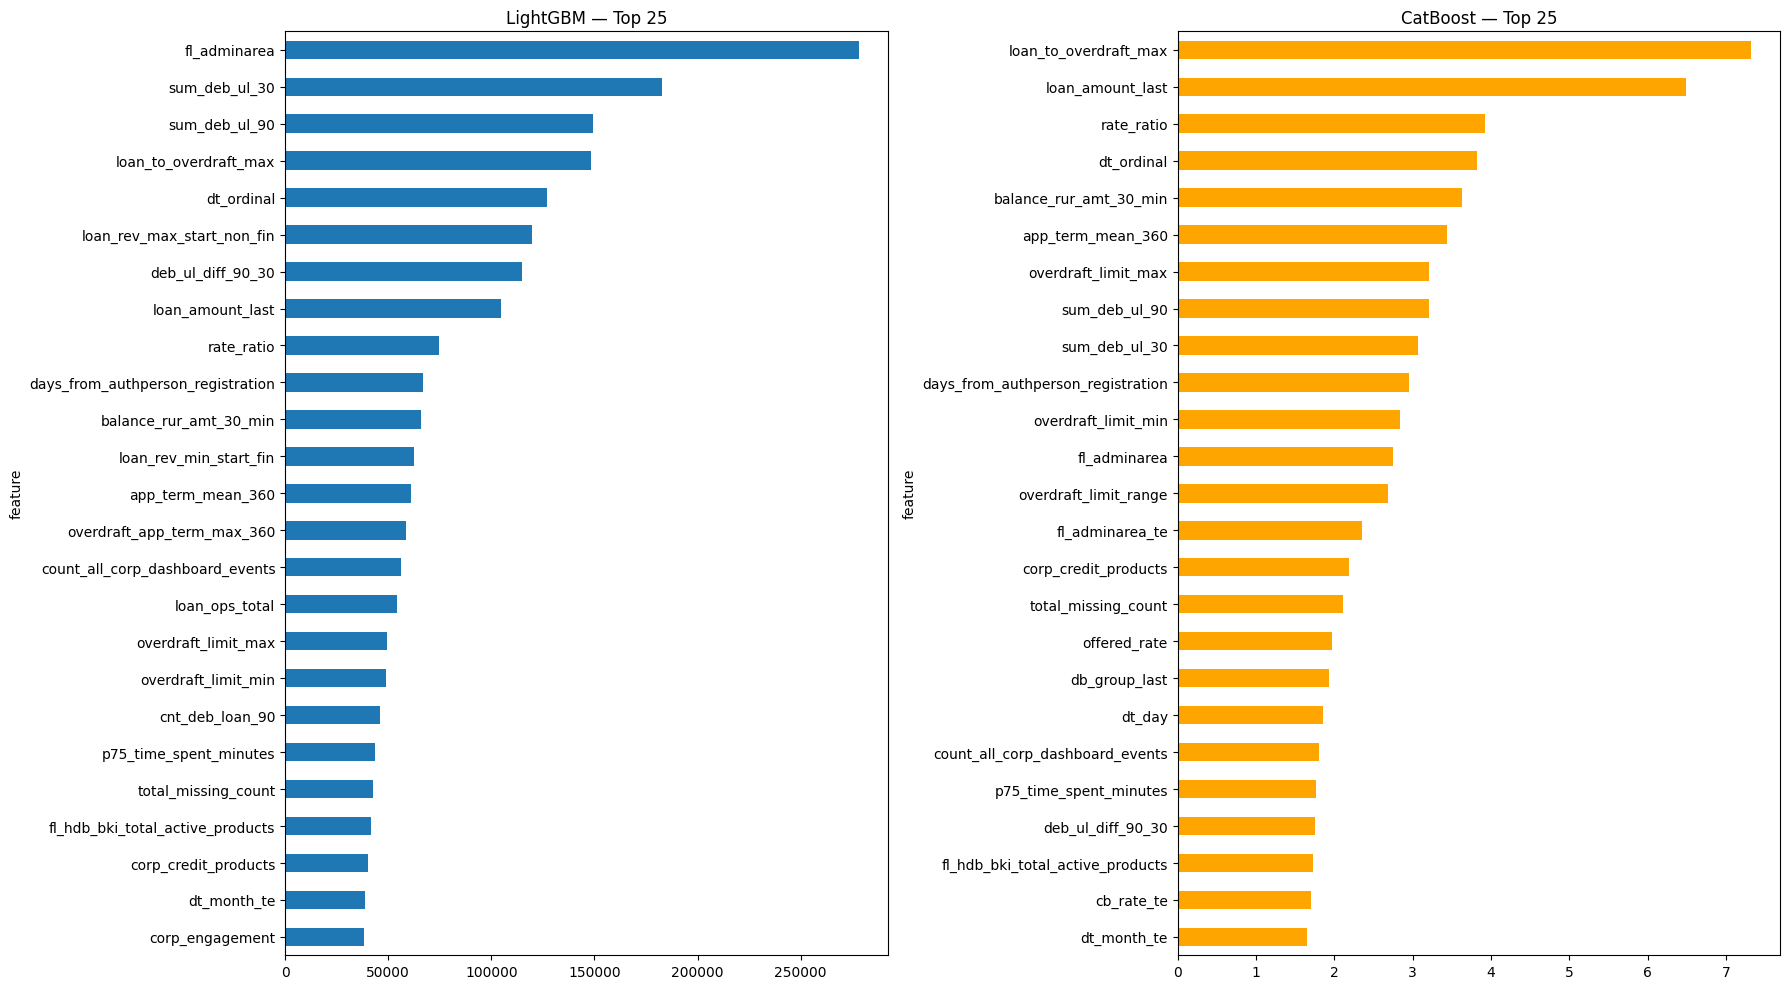

In [50]:
imp_df = pd.DataFrame({
    'feature': features_v3,
    'lgb_gain': np.mean([m.feature_importance('gain') for m in lgb_models_v3], axis=0),
    'cb_imp': np.mean([m.get_feature_importance() for m in cb_models_v3], axis=0),
})

fig, axes = plt.subplots(1, 2, figsize=(18, 10))
imp_df.sort_values('lgb_gain').tail(25).plot.barh(x='feature', y='lgb_gain', ax=axes[0], legend=False)
axes[0].set_title('LightGBM — Top 25')
imp_df.sort_values('cb_imp').tail(25).plot.barh(x='feature', y='cb_imp', ax=axes[1], legend=False, color='orange')
axes[1].set_title('CatBoost — Top 25')
plt.tight_layout()
plt.show()

Распределение предсказаний

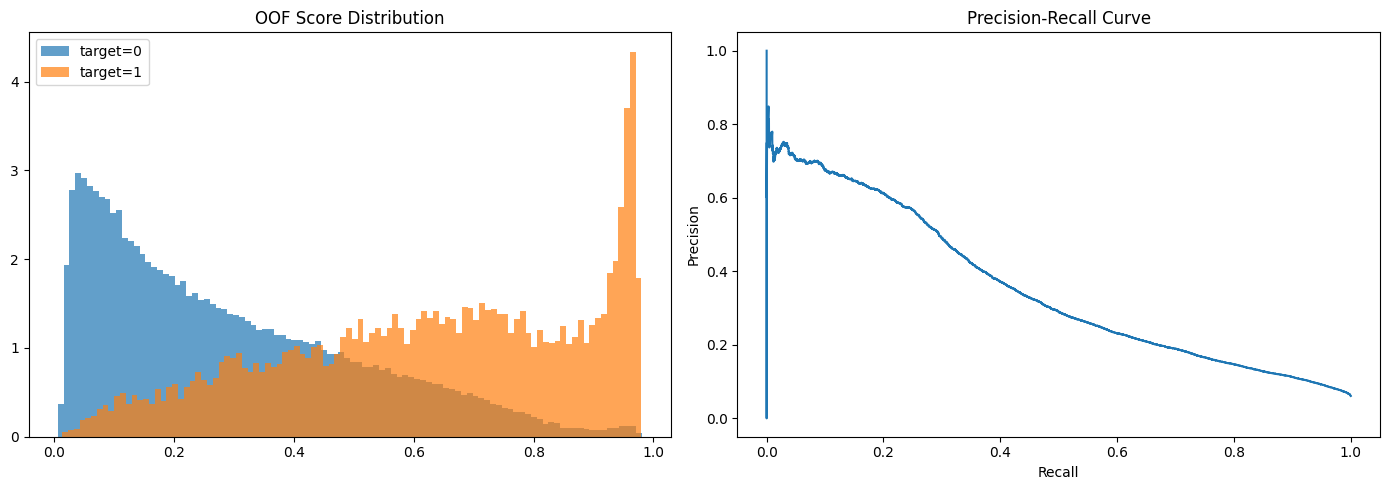

In [51]:
avg_oof = np.mean(list(all_oofs.values()), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(avg_oof[y_train == 0], bins=100, alpha=0.7, label='target=0', density=True)
axes[0].hist(avg_oof[y_train == 1], bins=100, alpha=0.7, label='target=1', density=True)
axes[0].set_title('OOF Score Distribution')
axes[0].legend()

precision, recall, _ = precision_recall_curve(y_train, avg_oof)
axes[1].plot(recall, precision)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
plt.tight_layout()
plt.show()

In [52]:
submission = pd.DataFrame({
    'front_id': test_df[ID_COL].astype(int).values,
    'target_value': final_preds
})

print(submission['target_value'].describe())
submission.to_csv('submission_2.csv', index=False)


count    36311.000000
mean         0.414166
std          0.219706
min          0.016514
25%          0.239078
50%          0.389379
75%          0.563793
max          0.976128
Name: target_value, dtype: float64
submission.csv saved (36311 rows)
